# Adaptive Sampling POMCP — Control Panel

End-to-end notebook for running the POMCP paper algorithm
("Adaptive Sampling using POMDPs with Domain-Specific Considerations")
on OceanBench data.

**Sections:**
1. Configuration block
2. Load data (DataProvider or synthetic fallback)
3. Build action space / WaypointGraph
4. Visualize truth field
5. Initialize belief model
6. Run POMCP
7. Results: trajectory, rewards, prediction, error
8. Switch exploration / commitment strategies
9. Save results

## 1. Configuration

Edit the block below to control the scenario, model, and POMCP parameters.

In [12]:
# ===== EDIT THIS BLOCK =====

PRODUCT_ID = "copernicus_phy_reanalysis_001_030"
REGION = {"lon": [-92, -86], "lat": [22, 28]}
TIME_WINDOW = ("2014-01-01", "2014-01-07")
VARIABLE = "temp"

# Graph
N_LAT, N_LON = 12, 12
CONNECTIVITY = "4"          # "4" or "8"
SPEED_MPS = 1.0

# Belief model
FIELD_MODEL = "gp"          # "gp" | "sparse_online_gp" | "svgp"
OBJECTIVE_C = 1.0           # exploration coefficient in mean + c*std
NOISE_VAR = 0.01

# POMCP
MAX_STEPS = 100
MAX_DEPTH = 8
DISCOUNT = 0.95
UCT_C = 1.0

# Exploration strategy: "uct" | "successive_rejects" | "ugapeb"
EXPLORATION = "uct"
# Commitment strategy: "none" | "fixed_k" | "ttest" | "ugapec"
COMMITMENT = "none"
COMMITMENT_K = 3            # for fixed_k
COMMITMENT_P = 0.05         # for ttest

# Rollout schedule: "constant" | "increasing" | "beta"
ROLLOUT_SCHEDULE = "constant"
ROLLOUT_N = 300

# Misc
SEED = 42
N_INIT_OBS = 20             # initial random observations before POMCP
EVAL_GRID_RES = 30          # eval grid resolution per axis

# =============================

## 2. Setup & Imports

In [13]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for pkg in [
    "oceanbench-core", "oceanbench-models", "oceanbench-env",
    "oceanbench-policies", "oceanbench-data-provider", "oceanbench-viz",
    "oceanbench-tasks", "oceanbench-bench",
]:
    d = ROOT / pkg
    if d.exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))

import numpy as np
import matplotlib.pyplot as plt

from oceanbench_core.types import ObservationBatch, QueryPoints, Scenario
from oceanbench_core import WaypointGraph

rng = np.random.default_rng(SEED)
print("Imports OK")

Imports OK


## 3. Load Data

Try DataProvider first; fall back to a smooth synthetic field.

In [14]:
region_dict = {
    "lat_min": REGION["lat"][0], "lat_max": REGION["lat"][1],
    "lon_min": REGION["lon"][0], "lon_max": REGION["lon"][1],
}

USE_REAL_DATA = False
truth_ds = None

try:
    from oceanbench_data_provider import DataProvider
    provider = DataProvider()
    truth_ds = provider.get_subset(
        product_id=PRODUCT_ID,
        variables=[VARIABLE],
        region=region_dict,
        time_range=(np.datetime64(TIME_WINDOW[0]), np.datetime64(TIME_WINDOW[1])),
    )
    USE_REAL_DATA = True
    print(f"Loaded real data: {truth_ds}")
except Exception as e:
    print(f"DataProvider unavailable ({e}), using synthetic fallback.")

# --- synthetic fallback ---
def _synth_field(lat, lon):
    return (
        22.0
        + 3.0 * np.sin(0.8 * (lat - region_dict["lat_min"]))
        + 2.5 * np.cos(0.6 * (lon - region_dict["lon_min"]))
    )

# Dense eval grid (used for truth and error maps).
eval_lats = np.linspace(region_dict["lat_min"], region_dict["lat_max"], EVAL_GRID_RES)
eval_lons = np.linspace(region_dict["lon_min"], region_dict["lon_max"], EVAL_GRID_RES)
eval_lat_mesh, eval_lon_mesh = np.meshgrid(eval_lats, eval_lons, indexing="ij")
eval_lats_flat = eval_lat_mesh.ravel()
eval_lons_flat = eval_lon_mesh.ravel()

if USE_REAL_DATA:
    from oceanbench_env import OceanTruthField
    truth_field = OceanTruthField(dataset=truth_ds, variable=VARIABLE)
    eval_qp = QueryPoints(
        lats=eval_lats_flat, lons=eval_lons_flat,
        times=np.full(eval_lats_flat.shape, truth_ds.time.values[0]),
    )
    truth_values = truth_field.query_array(eval_qp)
else:
    truth_values = _synth_field(eval_lats_flat, eval_lons_flat)

# Replace NaNs with mean for robustness.
nan_mask = np.isnan(truth_values)
if nan_mask.any():
    truth_values[nan_mask] = np.nanmean(truth_values)
    print(f"Replaced {nan_mask.sum()} NaN truth values with mean.")

print(f"Truth field: shape={truth_values.shape}, range=[{truth_values.min():.2f}, {truth_values.max():.2f}]")

DataProvider unavailable ('DataProvider' object has no attribute 'get_subset'), using synthetic fallback.
Truth field: shape=(900,), range=[16.51, 27.49]


## 4. Build Action Space / WaypointGraph

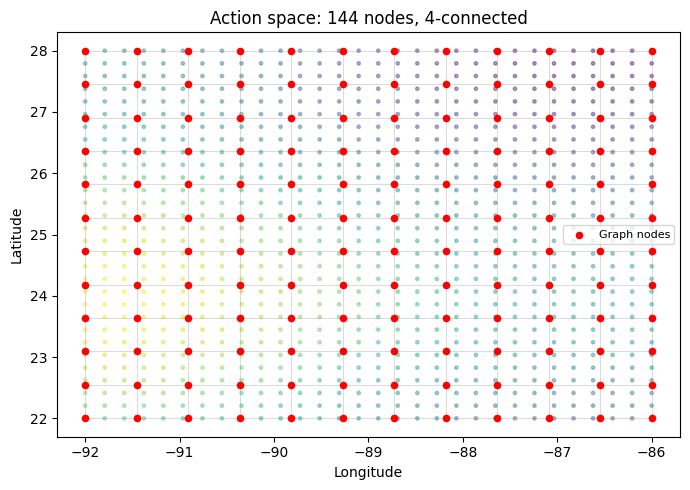

In [15]:
graph = WaypointGraph.grid(
    region_dict, N_LAT, N_LON,
    speed_mps=SPEED_MPS, connectivity=CONNECTIVITY, seed=SEED,
)
nodes = list(graph.graph.nodes)
node_lats = np.array([graph.graph.nodes[n]["lat"] for n in nodes])
node_lons = np.array([graph.graph.nodes[n]["lon"] for n in nodes])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap="viridis", s=6, alpha=0.4)
ax.scatter(node_lons, node_lats, c="red", s=20, zorder=5, label="Graph nodes")
for u, v in graph.graph.edges:
    ax.plot(
        [graph.graph.nodes[u]["lon"], graph.graph.nodes[v]["lon"]],
        [graph.graph.nodes[u]["lat"], graph.graph.nodes[v]["lat"]],
        "gray", linewidth=0.4, alpha=0.5,
    )
ax.set_title(f"Action space: {len(nodes)} nodes, {CONNECTIVITY}-connected")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Truth Map

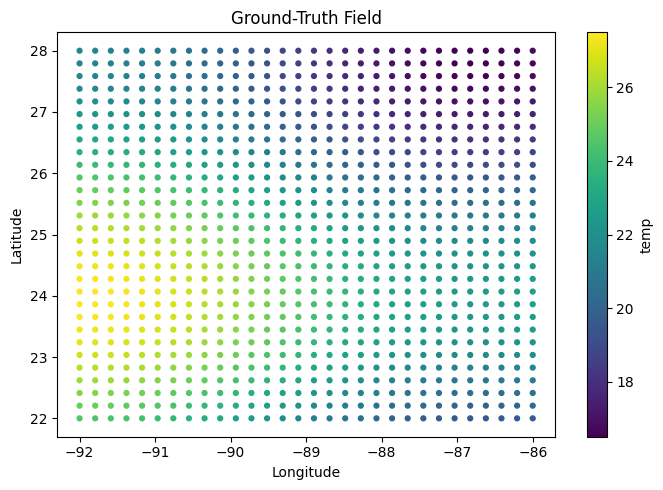

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap="viridis", s=12)
plt.colorbar(sc, ax=ax, label=VARIABLE)
ax.set_title("Ground-Truth Field")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

## 6. Initialize Belief Model

Seed the model with a few random observations so POMCP has an initial belief.

In [17]:
# Select field model.
model = None
model_name = FIELD_MODEL

if model_name == "sparse_online_gp":
    try:
        from oceanbench_models.belief.field.sparse_online_gp import SparseOnlineGPFieldModel
        model = SparseOnlineGPFieldModel(
            {"n_inducing": 30, "include_time": False, "include_depth": False}, seed=SEED,
        )
        print("Using SparseOnlineGPFieldModel")
    except Exception as e:
        print(f"SparseOnlineGP unavailable ({e}), falling back to GP.")
        model_name = "gp"

if model_name == "svgp":
    try:
        from oceanbench_models.belief.field.svgp_gpytorch import SVGPGPyTorchFieldModel
        model = SVGPGPyTorchFieldModel(
            {"n_inducing": 30, "include_time": False, "include_depth": False}, seed=SEED,
        )
        print("Using SVGPGPyTorchFieldModel")
    except Exception as e:
        print(f"SVGP unavailable ({e}), falling back to GP.")
        model_name = "gp"

if model is None:
    from oceanbench_models.belief.field.gp import GPFieldModel
    model = GPFieldModel(
        {"lengthscale": 1.5, "variance": 4.0, "noise": 0.1,
         "include_time": False, "include_depth": False},
        seed=SEED,
    )
    print("Using GPFieldModel")

# Initial observations.
init_lats = rng.uniform(region_dict["lat_min"], region_dict["lat_max"], N_INIT_OBS)
init_lons = rng.uniform(region_dict["lon_min"], region_dict["lon_max"], N_INIT_OBS)
# Query truth at init locations.
dists_init = np.linalg.norm(
    np.stack([eval_lats_flat, eval_lons_flat], axis=1)[None, :, :]
    - np.stack([init_lats, init_lons], axis=1)[:, None, :],
    axis=2,
)
nearest_idx = np.argmin(dists_init, axis=1)
init_values = truth_values[nearest_idx] + rng.normal(0, np.sqrt(NOISE_VAR), N_INIT_OBS)

init_obs = ObservationBatch(
    lats=init_lats, lons=init_lons, values=init_values, variable=VARIABLE,
)
model.fit(init_obs)
print(f"Belief model fitted with {N_INIT_OBS} initial observations.")

Using GPFieldModel
Belief model fitted with 20 initial observations.


## 7. Run POMCP

In [18]:
import time as _time

from oceanbench_policies.pomdp import (
    BeliefAdapter, POMCPConfig, POMCPPolicy, POMDPObservation, POMDPState,
)

# Build belief adapter.
belief = BeliefAdapter(
    model, variable=VARIABLE,
    objective_c=OBJECTIVE_C, measurement_noise_var=NOISE_VAR,
)
belief.seed_observations(init_obs)

# Build commitment kwargs.
commit_kw = {}
if COMMITMENT == "fixed_k":
    commit_kw = {"k": COMMITMENT_K}
elif COMMITMENT == "ttest":
    commit_kw = {"p_threshold": COMMITMENT_P}

config = POMCPConfig(
    max_depth=MAX_DEPTH, discount=DISCOUNT, uct_c=UCT_C,
    objective_c=OBJECTIVE_C,
    exploration_strategy=EXPLORATION,
    commitment_strategy=COMMITMENT,
    commitment_kwargs=commit_kw,
    rollout_schedule=ROLLOUT_SCHEDULE,
    rollout_kwargs={"n": ROLLOUT_N},
    max_steps=MAX_STEPS,
    seed=SEED,
)

policy = POMCPPolicy(graph=graph, belief=belief, config=config)

# --- episode loop ---
start_node = nodes[len(nodes) // 2]
time0 = np.datetime64("2014-01-01T00:00:00")
state = POMDPState(node_id=start_node, time=time0, step=0)

rewards_log = []
pred_checkpoints = {}  # step -> (mean, std)
checkpoint_steps = set(range(0, MAX_STEPS, max(1, MAX_STEPS // 4)))

t0 = _time.perf_counter()

step = 0
while step < MAX_STEPS:
    actions = policy.plan_k_steps(state, task=None, constraints=None)

    for action in actions:
        if step >= MAX_STEPS:
            break

        # Simulate observation.
        dists = np.hypot(eval_lats_flat - action.lat, eval_lons_flat - action.lon)
        nearest = int(np.argmin(dists))
        true_val = truth_values[nearest]
        noisy_val = true_val + rng.normal(0, np.sqrt(NOISE_VAR))

        obs = POMDPObservation(
            value=noisy_val, noise_var=NOISE_VAR,
            lat=action.lat, lon=action.lon, time=state.time,
        )
        policy.observe(obs)

        reward = belief.reward_at(action.lat, action.lon)
        rewards_log.append(reward)

        # Prediction checkpoint.
        if step in checkpoint_steps:
            eval_qp = QueryPoints(lats=eval_lats_flat, lons=eval_lons_flat)
            pred_cp = model.predict(eval_qp)
            pred_checkpoints[step] = (pred_cp.mean.copy(), pred_cp.std.copy() if pred_cp.std is not None else None)

        state = POMDPState(
            node_id=action.target_node_id,
            time=state.time + np.timedelta64(1, "h"),
            step=step + 1,
        )
        step += 1

elapsed = _time.perf_counter() - t0
print(f"POMCP finished: {step} steps in {elapsed:.1f}s")
print(f"Exploration: {EXPLORATION}, Commitment: {COMMITMENT}")

POMCP finished: 100 steps in 149.0s
Exploration: uct, Commitment: none


## 8. Results

### 8a. Trajectory on Map

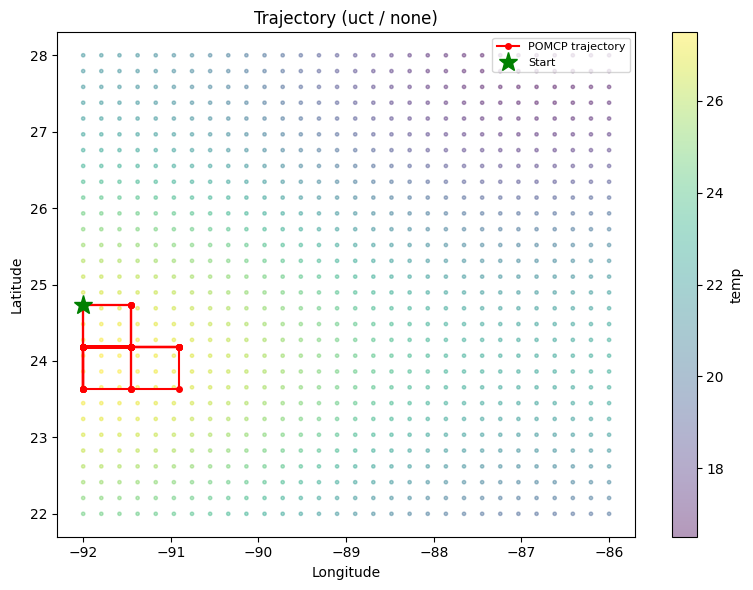

In [19]:
traj = policy.trajectory
traj_lats = [t["lat"] for t in traj]
traj_lons = [t["lon"] for t in traj]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap="viridis", s=6, alpha=0.4)
plt.colorbar(sc, ax=ax, label=VARIABLE)
ax.plot(traj_lons, traj_lats, "r-o", markersize=4, linewidth=1.5, label="POMCP trajectory")
ax.plot(traj_lons[0], traj_lats[0], "g*", markersize=14, label="Start")
ax.set_title(f"Trajectory ({EXPLORATION} / {COMMITMENT})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 8b. Reward Curve

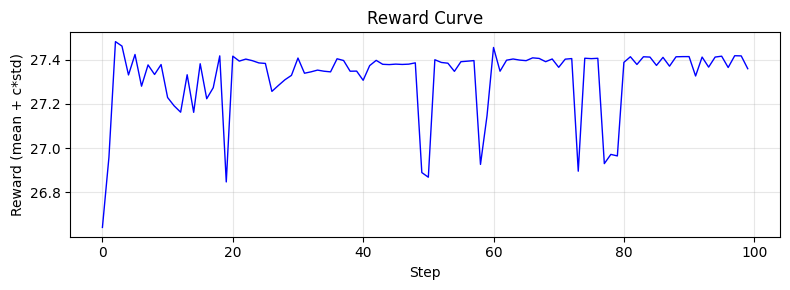

In [20]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(rewards_log, "b-", linewidth=1)
ax.set_xlabel("Step"); ax.set_ylabel("Reward (mean + c*std)")
ax.set_title("Reward Curve")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 8c. Prediction Mean & Uncertainty at Checkpoints

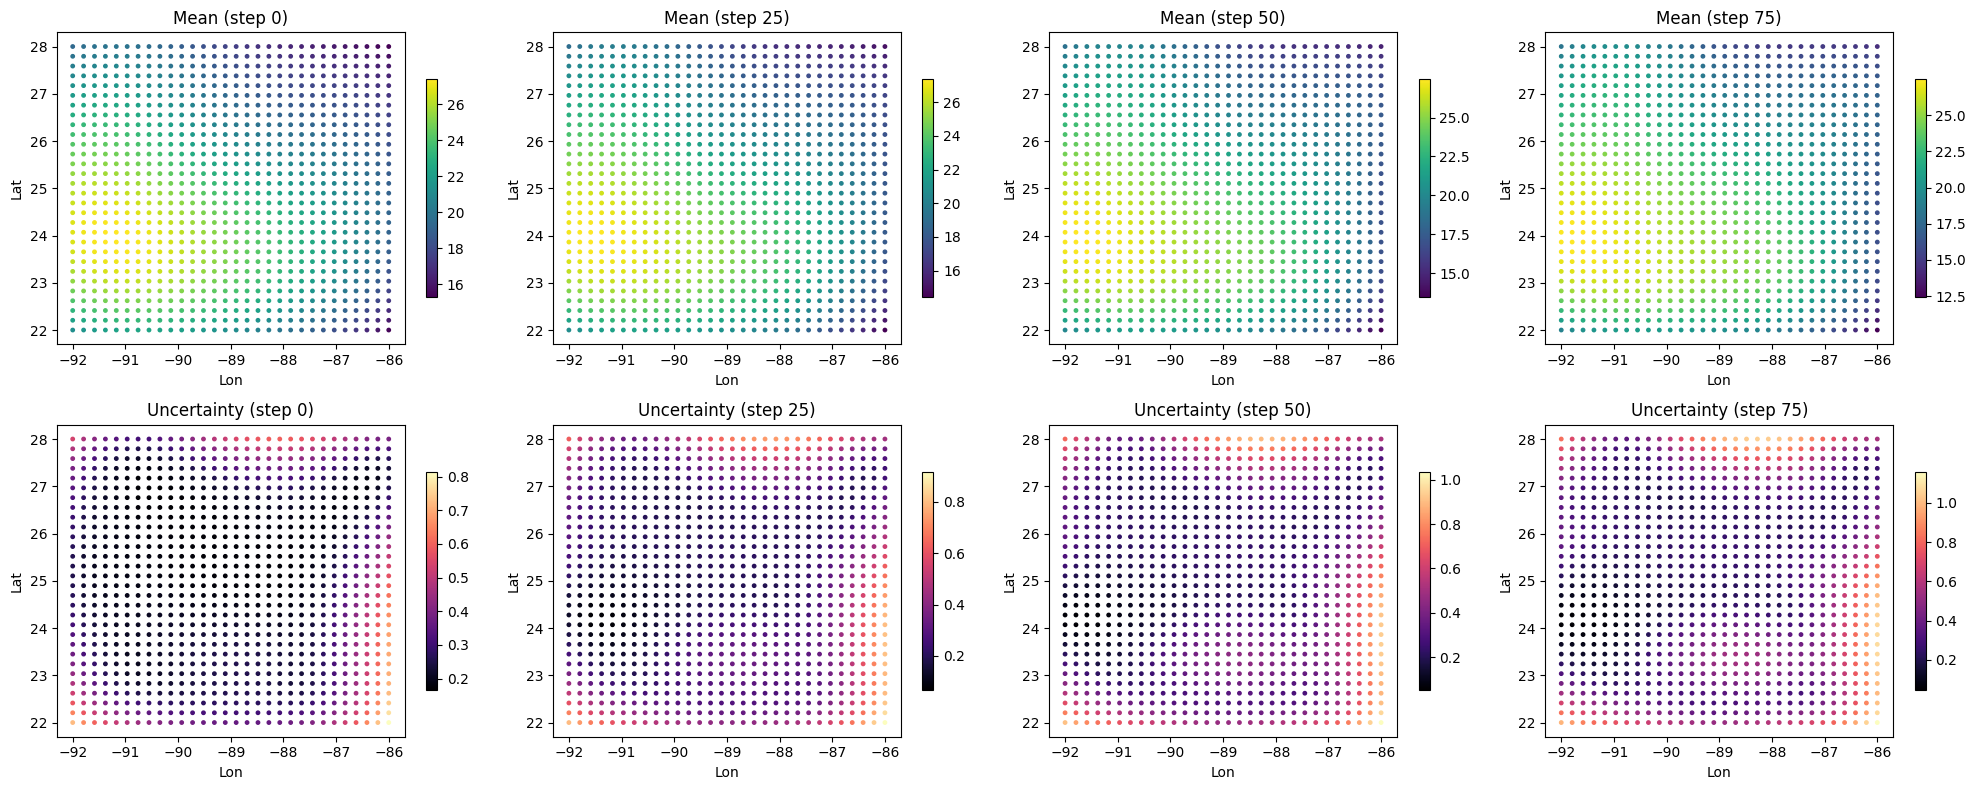

In [21]:
n_cp = len(pred_checkpoints)
if n_cp > 0:
    fig, axes = plt.subplots(2, n_cp, figsize=(5 * n_cp, 8), squeeze=False)
    for col, (cp_step, (mean, std)) in enumerate(sorted(pred_checkpoints.items())):
        ax = axes[0, col]
        sc = ax.scatter(eval_lons_flat, eval_lats_flat, c=mean, cmap="viridis", s=6)
        plt.colorbar(sc, ax=ax, shrink=0.7)
        ax.set_title(f"Mean (step {cp_step})")

        ax = axes[1, col]
        if std is not None:
            sc = ax.scatter(eval_lons_flat, eval_lats_flat, c=std, cmap="magma", s=6)
            plt.colorbar(sc, ax=ax, shrink=0.7)
        ax.set_title(f"Uncertainty (step {cp_step})")

    for ax in axes.flat:
        ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    plt.tight_layout(); plt.show()
else:
    print("No checkpoints recorded.")

### 8d. Error Map vs Truth

Final RMSE: 1.8632, MAE: 1.0924


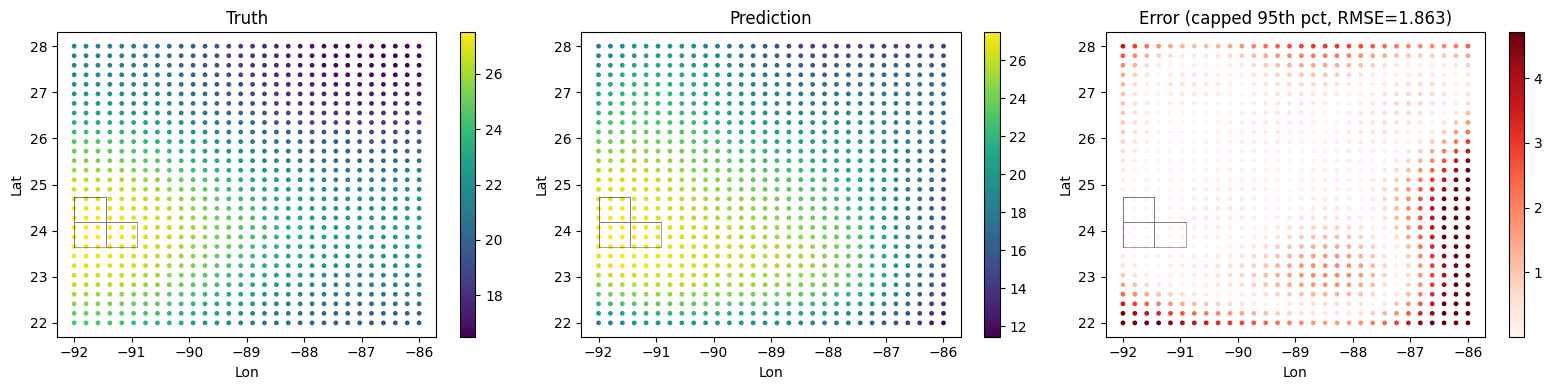

In [22]:
eval_qp_final = QueryPoints(lats=eval_lats_flat, lons=eval_lons_flat)
pred_final = model.predict(eval_qp_final)
error = np.abs(truth_values - pred_final.mean)
error_capped = np.minimum(error, np.percentile(error, 95))  # cap at 95th pct

rmse = np.sqrt(np.mean(error**2))
mae = np.mean(error)
print(f"Final RMSE: {rmse:.4f}, MAE: {mae:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sc = axes[0].scatter(eval_lons_flat, eval_lats_flat, c=truth_values, cmap="viridis", s=6)
plt.colorbar(sc, ax=axes[0]); axes[0].set_title("Truth")

sc = axes[1].scatter(eval_lons_flat, eval_lats_flat, c=pred_final.mean, cmap="viridis", s=6)
plt.colorbar(sc, ax=axes[1]); axes[1].set_title("Prediction")

sc = axes[2].scatter(eval_lons_flat, eval_lats_flat, c=error_capped, cmap="Reds", s=6)
plt.colorbar(sc, ax=axes[2]); axes[2].set_title(f"Error (capped 95th pct, RMSE={rmse:.3f})")

for ax in axes:
    ax.plot(traj_lons, traj_lats, "k-", linewidth=0.5, alpha=0.5)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

## 9. Switching Strategies

Change `EXPLORATION` and `COMMITMENT` in the config block above and re-run
cells 7-8 to compare strategies. Examples:

| Exploration | Commitment | Expected behaviour |
|---|---|---|
| `uct` | `none` | Baseline POMCP, re-plans every step |
| `successive_rejects` | `fixed_k` (k=3) | SR arm elimination, commits 3 steps |
| `ugapeb` | `ttest` (p=0.05) | UGapEb root selection, t-test commitment |
| `uct` | `ugapec` | Standard UCT, UGapEc confidence commitment |

## 10. Save Results

In [23]:
import json

results_dir = ROOT / "results" / "pomcp_notebook"
results_dir.mkdir(parents=True, exist_ok=True)

with (results_dir / "trajectory.json").open("w") as f:
    json.dump(policy.trajectory, f, indent=2, default=str)
with (results_dir / "rewards.json").open("w") as f:
    json.dump(rewards_log, f, indent=2)
with (results_dir / "metrics.json").open("w") as f:
    json.dump({"rmse": rmse, "mae": mae, "steps": step, "runtime_s": elapsed}, f, indent=2)

print(f"Results saved to {results_dir}")

Results saved to /home/shafezi/Documents/Projects/Data_Provider/oceanbench/results/pomcp_notebook
